In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df  = pd.read_csv('data.csv')
df.head(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:

df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [11]:
df.isna().sum().sum()

np.int64(1123500)

In [13]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [19]:
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('Not Cancelled')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna('Not Cancelled')
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna('Not Applicable')

df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(1)
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(1)
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(1)

In [16]:
df.isna().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                       48000
dtype: int64

In [25]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Not Cancelled,0.0,Not Cancelled,1.0,Vehicle Breakdown,NaN,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,48.21,4.1,4.3,UPI


In [24]:
df['Booking Value'] = df['Booking Value'].fillna(df['Booking Value'].mean())

In [26]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Not Cancelled,0.0,Not Cancelled,1.0,Vehicle Breakdown,NaN,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,NaN,48.21,4.1,4.3,UPI


In [30]:
df.drop(columns =['Booking Value'], inplace = True)

In [ ]:
df.isna().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                       48000
dtype: int64

In [48]:
df['Ride Distance'] = df['Ride Distance'].fillna(df['Ride Distance'].mean())
df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].mean())
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].mean())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].mean())
df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].mode()[0])
df.head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.456352,29.149636,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,24.637012,4.230992,4.9,Others
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.900000,14.000000,0.0,Not Cancelled,0.0,Not Cancelled,1.0,Vehicle Breakdown,5.730000,4.230992,4.9,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.400000,25.800000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,13.580000,4.900000,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.100000,28.500000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,34.020000,4.600000,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.300000,19.600000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,48.210000,4.100000,4.3,UPI
5,2024-02-06,09:44:56,"""CNR4096693""",Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.100000,18.100000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,4.850000,4.100000,4.6,UPI
6,2024-06-17,15:45:58,"""CNR2002539""",Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.100000,20.400000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,41.240000,4.000000,4.1,UPI
7,2024-03-19,17:37:37,"""CNR6568000""",Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.100000,16.500000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,6.560000,4.400000,4.2,UPI
8,2024-09-14,12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,8.456352,29.149636,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,24.637012,4.230992,4.9,Others
9,2024-12-16,19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.100000,26.000000,0.0,Not Cancelled,0.0,Not Cancelled,1.0,Other Issue,10.360000,4.230992,4.9,Cash


In [ ]:
df['Payment Method'].value_counts()

Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

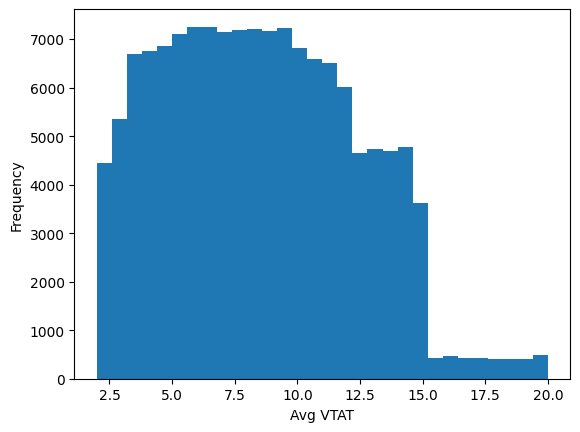

In [39]:
import matplotlib.pyplot as plt

plt.hist(df['Avg VTAT'].dropna(), bins=30)
plt.xlabel('Avg VTAT')
plt.ylabel('Frequency')
plt.show()

In [40]:
print(df['Avg VTAT'].skew())

0.30656478390930847


In [43]:
df['Payment Method'] = df['Payment Method'].fillna('Others')
df.head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,24.637012,4.230992,NaN,Others
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0.0,Not Cancelled,0.0,Not Cancelled,1.0,Vehicle Breakdown,5.730000,4.230992,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,13.580000,4.900000,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,34.020000,4.600000,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,48.210000,4.100000,4.3,UPI
5,2024-02-06,09:44:56,"""CNR4096693""",Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.1,18.1,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,4.850000,4.100000,4.6,UPI
6,2024-06-17,15:45:58,"""CNR2002539""",Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,41.240000,4.000000,4.1,UPI
7,2024-03-19,17:37:37,"""CNR6568000""",Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,6.560000,4.400000,4.2,UPI
8,2024-09-14,12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,24.637012,4.230992,NaN,Others
9,2024-12-16,19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,0.0,Not Cancelled,0.0,Not Cancelled,1.0,Other Issue,10.360000,4.230992,NaN,Cash


In [49]:
df.isnull().sum()

Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
Payment Method                       0
dtype: int64

In [53]:
df['Date'] = pd.to_datetime(df['Date'])

In [54]:
df.dtypes

Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Ride Distance                               float64
Driver Ratings                              float64
Customer Rating                             float64
Payment Meth

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

In [60]:
df['Vehicle Type'] = df['Vehicle Type'].str.title()
df['Vehicle Type'] = df['Vehicle Type'].str.strip()

In [61]:
df['Vehicle Type']

0                 Ebike
1              Go Sedan
2                  Auto
3         Premier Sedan
4                  Bike
              ...      
149995          Go Mini
149996          Go Mini
149997         Go Sedan
149998             Auto
149999    Premier Sedan
Name: Vehicle Type, Length: 150000, dtype: object

In [62]:
df.to_csv('cleaned_data.csv',index = False)

In [63]:
df2 = pd.read_csv('cleaned_data.csv')

In [64]:
df2.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",Ebike,Palam Vihar,Jhilmil,8.456352,29.149636,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,24.637012,4.230992,4.9,Others
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.900000,14.000000,0.0,Not Cancelled,0.0,Not Cancelled,1.0,Vehicle Breakdown,5.730000,4.230992,4.9,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.400000,25.800000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,13.580000,4.900000,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.100000,28.500000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,34.020000,4.600000,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.300000,19.600000,0.0,Not Cancelled,0.0,Not Cancelled,0.0,Not Applicable,48.210000,4.100000,4.3,UPI


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           150000 non-null  float64
 10  Cancelled Rides by Customer        150000 non-null  float64
 11  Reason for cancelling by Customer  1500

In [69]:
from sqlalchemy import create_engine

username = "root"
password = "sivapandian2005"   # unga MySQL password
host = "localhost"
port = "3306"
database = "uber"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

df.to_sql(
    "uber_bookings",
    engine,
    if_exists="replace",
    index=False
)

150000

In [70]:
import pymysql
print("PyMySQL installed successfully!")

PyMySQL installed successfully!


In [71]:
import pandas as pd

pd.read_sql("SELECT COUNT(*) FROM uber_bookings;", engine)

,COUNT(*)
0,150000


In [72]:
pd.read_sql("SELECT COUNT(*) FROM uber_bookings;", engine)

,COUNT(*)
0,150000


In [74]:
df.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [7]:

df.shape

(150000, 21)